**STEP 1 — Getting the Data**

In [1]:
import pandas as pd
import yfinance as yf
from fredapi import Fred
import warnings
warnings.filterwarnings("ignore")

In [2]:
fred = Fred(api_key='60884f2a57efba562d46409a0b552546')

In [3]:
print("Pulling S&P 500 data...")
sp500_raw = yf.download('^GSPC', start='1990-01-01', end='2024-12-31')
sp500 = sp500_raw[['Close']].copy()
sp500.columns = ['SP500']  # Flatten column name
sp500 = sp500.resample('MS').last()
sp500.index = sp500.index.tz_localize(None)  # Remove timezone

print("Pulling VIX data...")
vix_raw = yf.download('^VIX', start='1990-01-01', end='2024-12-31')
vix = vix_raw[['Close']].copy()
vix.columns = ['VIX']  # Flatten column name
vix = vix.resample('MS').last()
vix.index = vix.index.tz_localize(None)  # Remove timezone

print(f"S&P 500: {len(sp500)} months of data")
print(f"VIX: {len(vix)} months of data")

Pulling S&P 500 data...


[*********************100%***********************]  1 of 1 completed


Pulling VIX data...


[*********************100%***********************]  1 of 1 completed

S&P 500: 420 months of data
VIX: 420 months of data


In [4]:
print("Pulling data from FRED...")

# 2-Year Treasury yield
dgs2 = fred.get_series('DGS2',
                        observation_start='1990-01-01',
                        observation_end='2024-12-31')

# 10-Year Treasury yield
dgs10 = fred.get_series('DGS10',
                         observation_start='1990-01-01',
                         observation_end='2024-12-31')

# Federal Funds Rate (interest rates)
fed_rate = fred.get_series('FEDFUNDS',
                            observation_start='1990-01-01',
                            observation_end='2024-12-31')

# Inflation (Consumer Price Index)
cpi = fred.get_series('CPIAUCSL',
                       observation_start='1990-01-01',
                       observation_end='2024-12-31')

# Unemployment Rate
unemployment = fred.get_series('UNRATE',
                                observation_start='1990-01-01',
                                observation_end='2024-12-31')

# Credit Spread (corporate bond fear indicator)
credit_spread = fred.get_series('BAA10Y',
                                 observation_start='1990-01-01',
                                 observation_end='2024-12-31')

# Consumer Sentiment (University of Michigan)
consumer_sentiment = fred.get_series('UMCSENT',
                                      observation_start='1990-01-01',
                                      observation_end='2024-12-31')

print("All FRED data pulled successfully!")

Pulling data from FRED...
All FRED data pulled successfully!


In [5]:
# Convert everything to monthly frequency
macro = pd.DataFrame({
    'DGS2'              : dgs2.resample('MS').mean(),
    'DGS10'             : dgs10.resample('MS').mean(),
    'Fed_Rate'          : fed_rate.resample('MS').mean(),
    'CPI'               : cpi.resample('MS').mean(),
    'Unemployment'      : unemployment.resample('MS').mean(),
    'Credit_Spread'     : credit_spread.resample('MS').mean(),
    'Consumer_Sentiment': consumer_sentiment.resample('MS').mean()
})

# Yield curve = 10yr minus 2yr
# When this goes NEGATIVE = inverted yield curve = danger signal
macro['Yield_Curve'] = macro['DGS10'] - macro['DGS2']

# Inflation rate = year over year % change in CPI
macro['Inflation_Rate'] = macro['CPI'].pct_change(12) * 100

# Drop the raw CPI and individual yields (we have derived versions now)
macro = macro.drop(columns=['CPI', 'DGS2', 'DGS10'])

# Merge S&P 500, VIX, and macro data into one dataframe
df = sp500.join(vix, how='outer').join(macro, how='outer')

# Remove any rows with missing data
df = df.dropna()

print(f"Final dataset shape: {df.shape}")
print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
print(f"\nColumns: {list(df.columns)}")

Final dataset shape: (408, 8)
Date range: 1991-01-01 to 2024-12-01

Columns: ['SP500', 'VIX', 'Fed_Rate', 'Unemployment', 'Credit_Spread', 'Consumer_Sentiment', 'Yield_Curve', 'Inflation_Rate']


In [6]:
df.to_csv('market_risk_data.csv')
print("Data saved to market_risk_data.csv")
print("\nPreview:")
df.head(10)

Data saved to market_risk_data.csv

Preview:


,SP500,VIX,Fed_Rate,Unemployment,Credit_Spread,Consumer_Sentiment,Yield_Curve,Inflation_Rate
1991-01-01,343.929993,20.910000,6.91,6.4,2.358571,66.8,0.966667,5.647059
1991-02-01,367.070007,21.230000,6.25,6.6,2.213684,70.4,0.987895,5.312500
1991-03-01,375.220001,16.879999,6.12,6.8,1.980000,87.7,1.007000,4.821151
1991-04-01,375.339996,18.240000,5.91,6.7,1.903182,81.8,1.090909,4.809930
1991-05-01,389.829987,15.930000,5.78,6.9,1.795909,78.3,1.284091,5.034857
1991-06-01,371.160004,19.549999,5.90,6.9,1.678000,82.1,1.328000,4.695920
1991-07-01,387.809998,15.180000,5.82,6.8,1.621818,82.9,1.355000,4.367816
1991-08-01,395.429993,14.460000,5.66,6.9,1.745455,82.0,1.466818,3.799392
1991-09-01,387.859985,15.850000,5.45,6.9,1.864500,83.0,1.468500,3.396226
1991-10-01,392.450012,15.480000,5.21,7.0,1.964091,78.3,1.615000,2.848576


**STEP 2 — Creating the Target Variable Column**

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv("/Users/swaransh/DataspellProjects/Advanced Computing project/market_risk_data.csv",index_col=0, parse_dates=True)
print(df.columns)

Index(['SP500', 'VIX', 'Fed_Rate', 'Unemployment', 'Credit_Spread',
       'Consumer_Sentiment', 'Yield_Curve', 'Inflation_Rate'],
      dtype='str')


In [9]:
print(df.shape)
print(df.head())

(408, 8)
                 SP500        VIX  Fed_Rate  Unemployment  Credit_Spread  \
1991-01-01  343.929993  20.910000      6.91           6.4       2.358571   
1991-02-01  367.070007  21.230000      6.25           6.6       2.213684   
1991-03-01  375.220001  16.879999      6.12           6.8       1.980000   
1991-04-01  375.339996  18.240000      5.91           6.7       1.903182   
1991-05-01  389.829987  15.930000      5.78           6.9       1.795909   

            Consumer_Sentiment  Yield_Curve  Inflation_Rate  
1991-01-01                66.8     0.966667        5.647059  
1991-02-01                70.4     0.987895        5.312500  
1991-03-01                87.7     1.007000        4.821151  
1991-04-01                81.8     1.090909        4.809930  
1991-05-01                78.3     1.284091        5.034857  


In [10]:
def create_target(df, forward_months=3, drop_threshold=0.10):
    target = []
    for i in range(len(df)):
        current_price = df['SP500'].iloc[i]

        end_index = min(i + forward_months + 1, len(df))
        future_prices = df['SP500'].iloc[i+1:end_index]

        if len(future_prices) == 0:
            target.append(0)
            continue
        lowest_future_price = future_prices.min()
        max_drop = (current_price - lowest_future_price) / current_price


        if max_drop >= drop_threshold:
            target.append(1)
        else:
            target.append(0)

    return target


df['Target'] = create_target(df)

print(df['Target'].value_counts())
print(f"\ntotal months: {len(df)}")
print(f"months with correction (1): {df['Target'].sum()}")
print(f"Safe months (0): {(df['Target'] == 0).sum()}")

Target
0    374
1     34
Name: count, dtype: int64

total months: 408
months with correction (1): 34
Safe months (0): 374


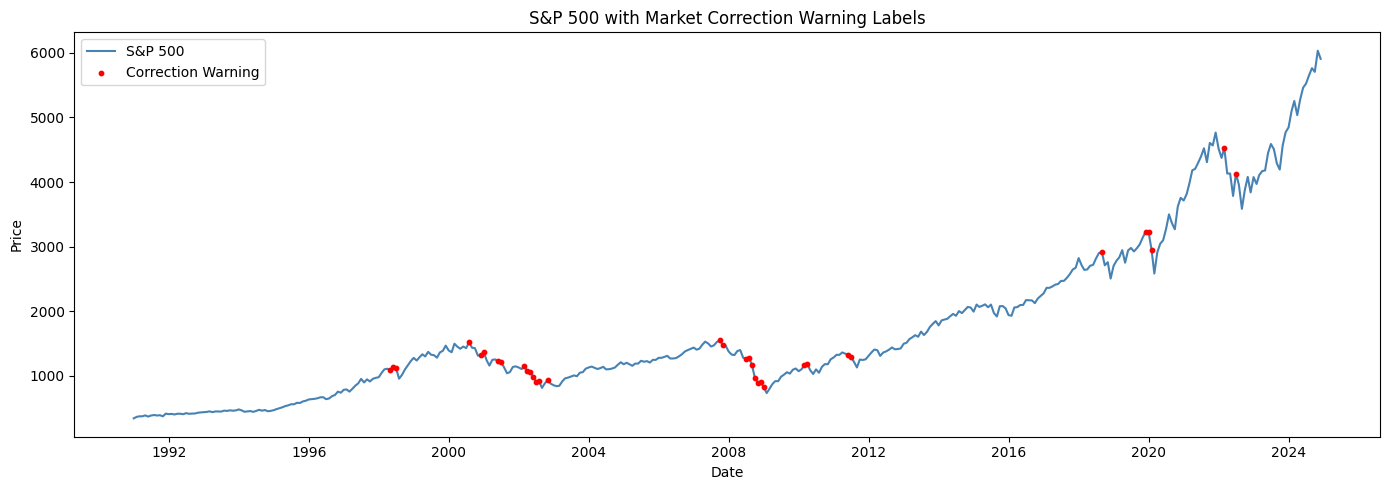

In [11]:
plt.figure(figsize=(14,5))
plt.plot(df.index, df['SP500'], color='steelblue', linewidth=1.5, label='S&P 500')
correction_months = df[df['Target'] == 1]
plt.scatter(correction_months.index, correction_months['SP500'],
            color='red', s=10, label='Correction Warning', zorder=5)

plt.title('S&P 500 with Market Correction Warning Labels')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
df.to_csv('market_risk_data_labelled.csv')
print("File saved: market_risk_data_labelled.csv")

File saved: market_risk_data_labelled.csv


In [13]:
pd.read_csv("/Users/swaransh/DataspellProjects/Advanced Computing project/market_risk_data_labelled.csv")

,Unnamed: 0,SP500,VIX,Fed_Rate,Unemployment,Credit_Spread,Consumer_Sentiment,Yield_Curve,Inflation_Rate,Target
0,1991-01-01,343.929993,20.910000,6.91,6.4,2.358571,66.8,0.966667,5.647059,0
1,1991-02-01,367.070007,21.230000,6.25,6.6,2.213684,70.4,0.987895,5.312500,0
2,1991-03-01,375.220001,16.879999,6.12,6.8,1.980000,87.7,1.007000,4.821151,0
3,1991-04-01,375.339996,18.240000,5.91,6.7,1.903182,81.8,1.090909,4.809930,0
4,1991-05-01,389.829987,15.930000,5.78,6.9,1.795909,78.3,1.284091,5.034857,0
...,...,...,...,...,...,...,...,...,...,...
403,2024-08-01,5648.399902,15.000000,5.33,4.2,1.733636,67.9,-0.094545,2.607144,0
404,2024-09-01,5762.479980,16.730000,5.13,4.1,1.694500,70.1,0.101000,2.426483,0
405,2024-10-01,5705.450195,23.160000,4.83,4.1,1.538636,70.5,0.123182,2.578844,0
406,2024-11-01,6032.379883,13.510000,4.64,4.2,1.421579,71.8,0.098421,2.719472,0


**STEP 3 — Exploratory Data Analysis**

In [14]:
print(df.describe())

             SP500         VIX    Fed_Rate  Unemployment  Credit_Spread  \
count   408.000000  408.000000  408.000000    408.000000     408.000000   
mean   1739.558306   19.430809    2.686520      5.717157       2.323890   
std    1254.230094    7.536579    2.217661      1.773390       0.717332   
min     343.929993    9.510000    0.050000      3.400000       1.289524   
25%     962.012527   13.707500    0.190000      4.400000       1.790157   
50%    1302.829956   17.400000    2.305000      5.400000       2.182159   
75%    2112.079895   23.384999    5.145000      6.700000       2.735471   
max    6032.379883   59.889999    6.910000     14.800000       6.013636   

       Consumer_Sentiment  Yield_Curve  Inflation_Rate      Target  
count           408.00000   408.000000      408.000000  408.000000  
mean             85.32451     1.042844        2.621674    0.083333  
std              13.38196     0.927971        1.567408    0.276725  
min              50.00000    -0.929000       -1.

In [15]:
df.isnull().sum()


SP500                 0
VIX                   0
Fed_Rate              0
Unemployment          0
Credit_Spread         0
Consumer_Sentiment    0
Yield_Curve           0
Inflation_Rate        0
Target                0
dtype: int64

In [16]:
df.duplicated()

1991-01-01    False
1991-02-01    False
1991-03-01    False
1991-04-01    False
1991-05-01    False
              ...  
2024-08-01    False
2024-09-01    False
2024-10-01    False
2024-11-01    False
2024-12-01    False
Length: 408, dtype: bool

Target
0    374
1     34
Name: count, dtype: int64

Correction rate: 8.3% months


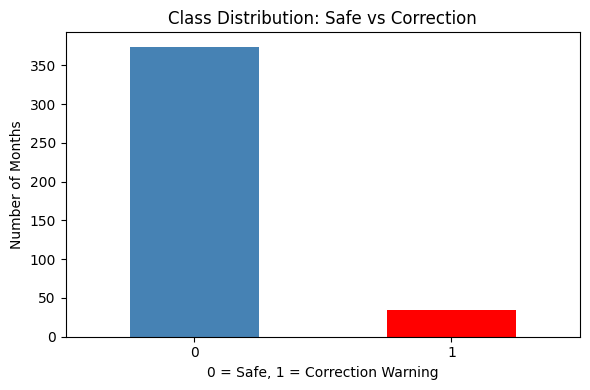

In [17]:
#Chart 1 - No.of market corrections
target_counts = df['Target'].value_counts()
print(target_counts)
print(f"\nCorrection rate: {df['Target'].mean()*100:.1f}% months")

# Bar chart
target_counts.plot(kind='bar', color=['steelblue', 'red'], figsize=(6,4))
plt.title('Class Distribution: Safe vs Correction')
plt.xlabel('0 = Safe, 1 = Correction Warning')
plt.ylabel('Number of Months')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


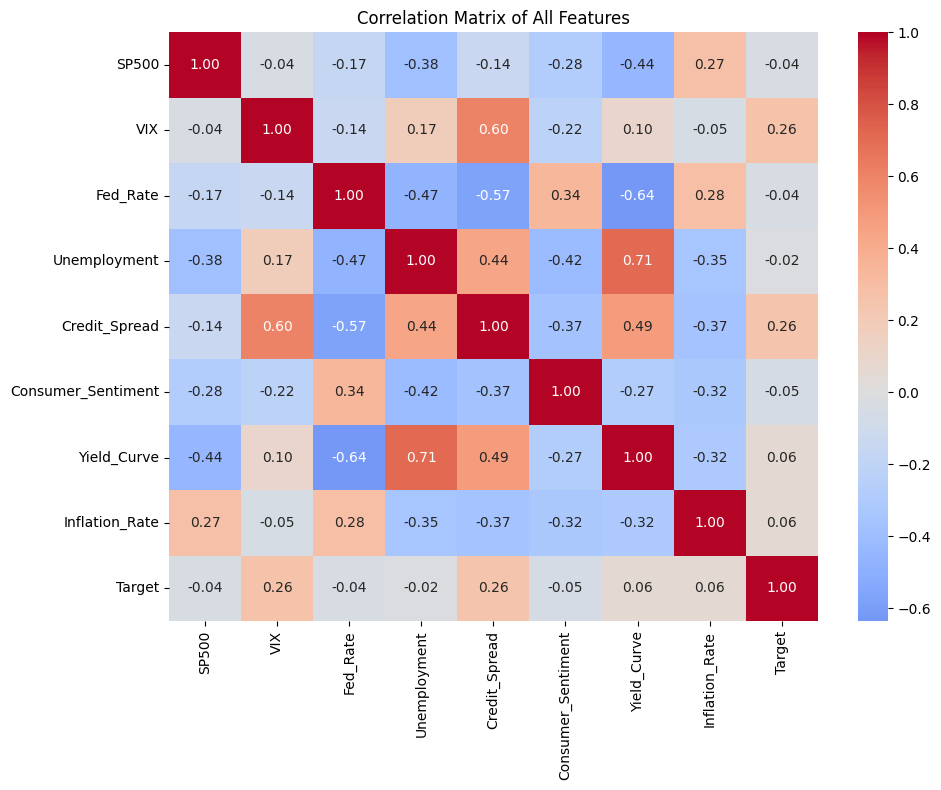

In [18]:
#Chart 2 -  correlation between features

plt.figure(figsize=(10, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix of All Features')
plt.tight_layout()
plt.show()

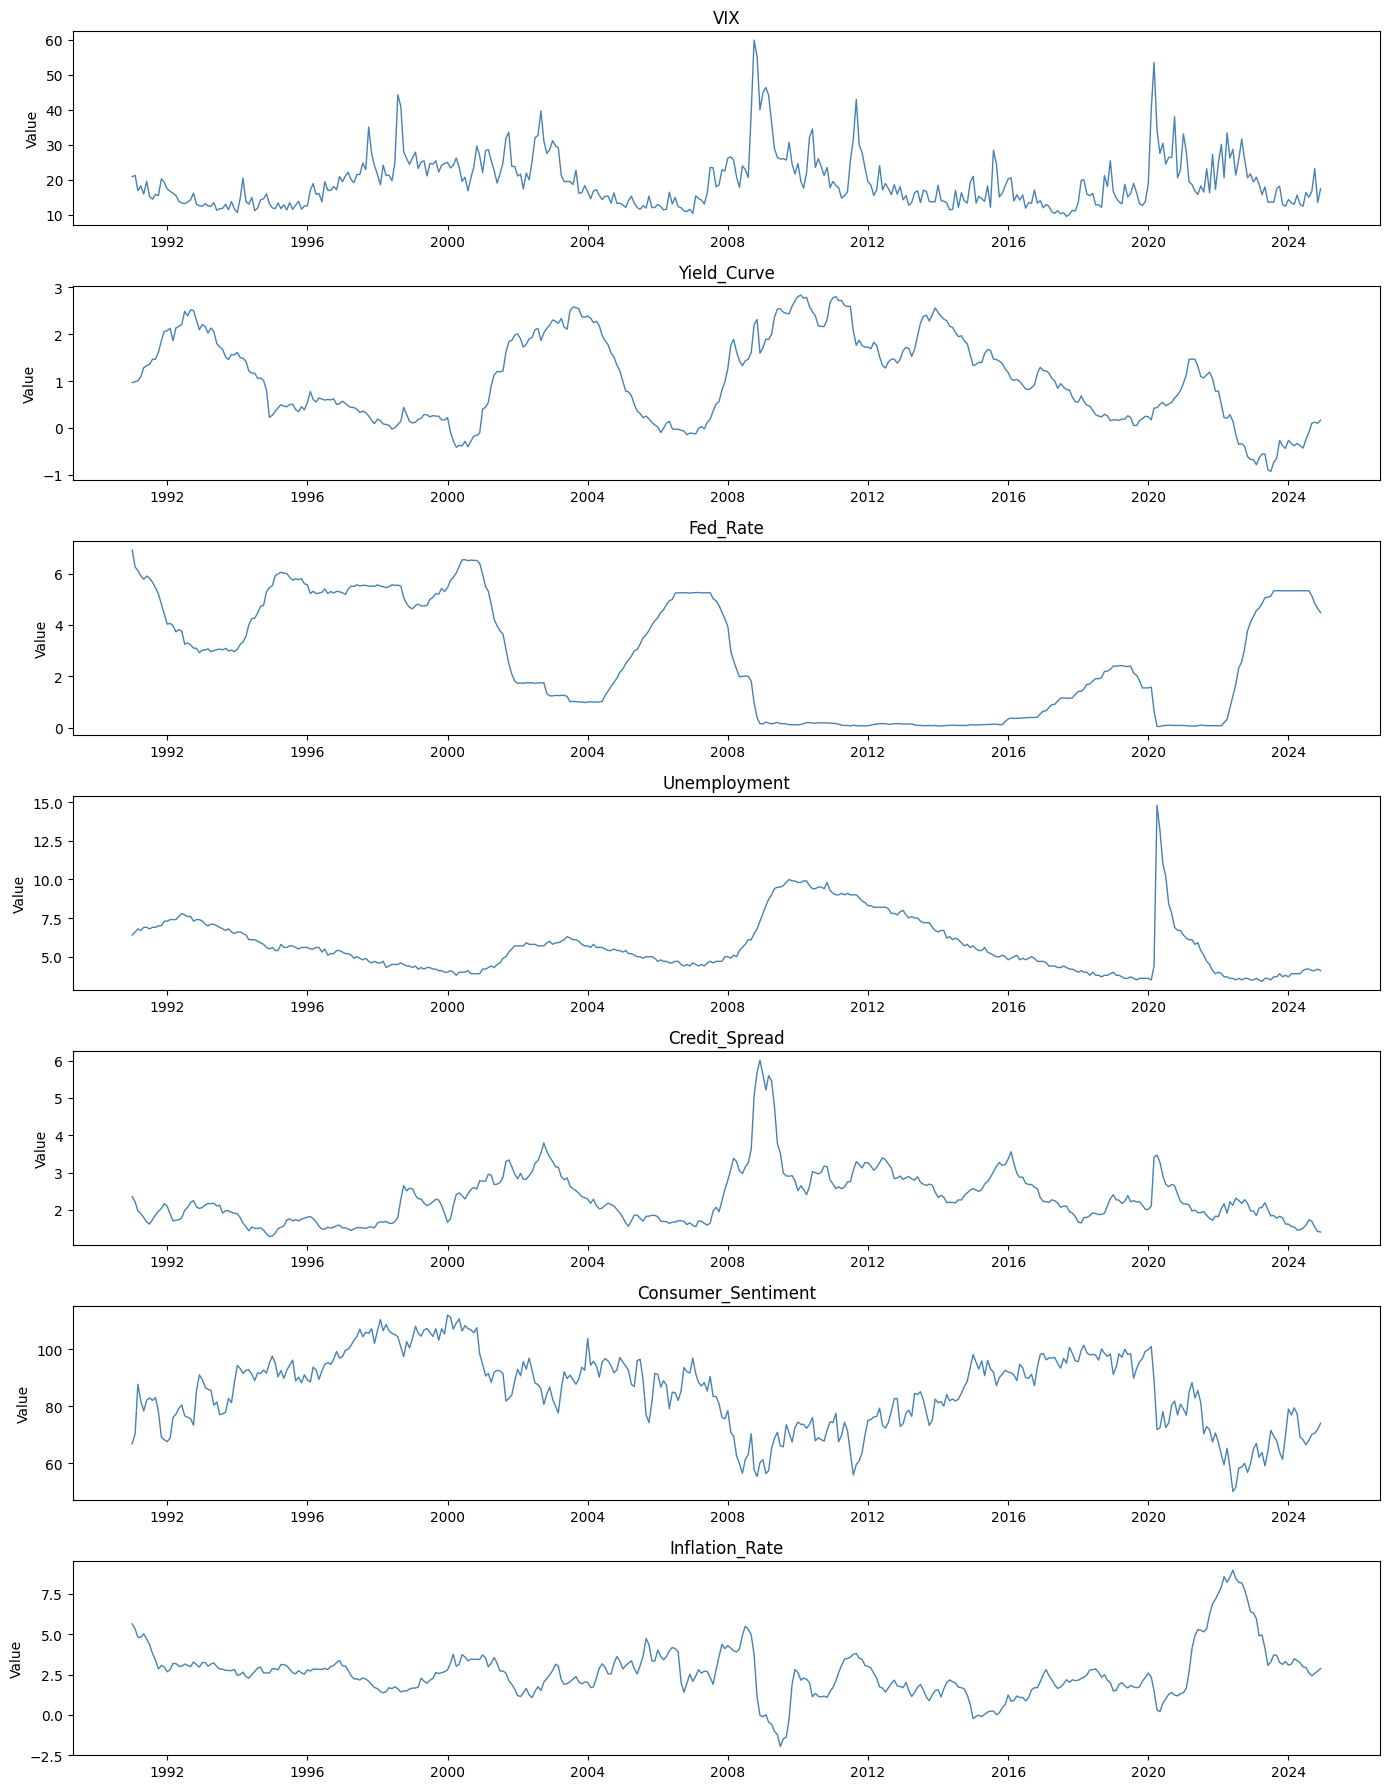

In [19]:
#Chart 3 - time plots of all features

features = ['VIX', 'Yield_Curve', 'Fed_Rate', 'Unemployment',
            'Credit_Spread', 'Consumer_Sentiment', 'Inflation_Rate']

fig, axes = plt.subplots(len(features), 1, figsize=(14, 18))

for i, feature in enumerate(features):
    axes[i].plot(df.index, df[feature], color='steelblue', linewidth=1)
    axes[i].set_title(feature)
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()

In [20]:

features = ['VIX', 'Yield_Curve', 'Fed_Rate', 'Unemployment',
            'Credit_Spread', 'Consumer_Sentiment', 'Inflation_Rate']


for feature in features:
    df[feature + '_lag1'] = df[feature].shift(1)


for feature in features:
    df[feature + '_lag3'] = df[feature].shift(3)

print("Lag features!")
print(f"Columns : {df.shape[1]}")

Lag features!
Columns : 23


**STEP 4 — Feature Engineering**

In [21]:
# last 3 months average
for feature in features:
    df[feature + '_roll3'] = df[feature].rolling(window=3).mean()


print("Rolling features!")
print(f"Columns : {df.shape[1]}")

Rolling features!
Columns : 30


In [22]:
df = df.dropna()

print(f"Shape after dropping NaN: {df.shape}")

# Save
df.to_csv('market_risk_data_features.csv')
print("Saved!")

Shape after dropping NaN: (405, 30)
Saved!


In [23]:
X = df.drop(columns=['Target', 'SP500'])
y = df['Target']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print(f"\nCrash months: {y.sum()}")
print(f"Safe months: {(y==0).sum()}")

Features (X) shape: (405, 28)
Target (y) shape: (405,)

Crash months: 34
Safe months: 371


**STEP 5 — Train-Test Split and Class Imbalance Treatment (SMOTE)**

In [24]:
split_index = int(len(df) * 0.80)

X_train = X.iloc[:split_index]   # 80% rows
X_test  = X.iloc[split_index:]   # 20% rows
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nTrain crash months: {y_train.sum()}")
print(f"Test crash months: {y_test.sum()}")

Training set: (324, 28)
Test set: (81, 28)

Train crash months: 28
Test crash months: 6


In [25]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE - Crash: {y_train.sum()}, Safe: {(y_train==0).sum()}")
print(f"After SMOTE  - Crash: {y_train_smote.sum()}, Safe: {(y_train_smote==0).sum()}")

Before SMOTE - Crash: 28, Safe: 296
After SMOTE  - Crash: 296, Safe: 296


**STEP 6 — Model Training and Evaluation**

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported")

Libraries imported


In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_smote)

X_test_scaled = scaler.transform(X_test)

print("Scaling done!")

Scaling done!


In [28]:
# Model 1: Logistic Regression
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_smote)
print("Logistic Regression trained!")

# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train_smote, y_train_smote)
print("Random Forest trained!")

# Model 3: XGBoost — scale_pos_weight=10
xgb = XGBClassifier(
    scale_pos_weight=10,
    random_state=42,
    eval_metric='logloss',
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05
)
xgb.fit(X_train_smote, y_train_smote)
print("XGBoost trained!")

Logistic Regression trained!
Random Forest trained!
XGBoost trained!


In [29]:
models = {
    'Logistic Regression': (lr, X_test_scaled),
    'Random Forest':       (rf, X_test),
    'XGBoost':             (xgb, X_test)
}

for name, (model, X) in models.items():
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= 0.2).astype(int)
    print(classification_report(y_test, y_pred, target_names=['Safe', 'Crash']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}")


  Logistic Regression
              precision    recall  f1-score   support

        Safe       0.93      0.83      0.87        75
       Crash       0.07      0.17      0.10         6

    accuracy                           0.78        81
   macro avg       0.50      0.50      0.49        81
weighted avg       0.86      0.78      0.82        81

ROC-AUC: 0.684

  Random Forest
              precision    recall  f1-score   support

        Safe       0.91      0.57      0.70        75
       Crash       0.06      0.33      0.10         6

    accuracy                           0.56        81
   macro avg       0.49      0.45      0.40        81
weighted avg       0.85      0.56      0.66        81

ROC-AUC: 0.394

  XGBoost
              precision    recall  f1-score   support

        Safe       0.93      0.75      0.83        75
       Crash       0.10      0.33      0.15         6

    accuracy                           0.72        81
   macro avg       0.51      0.54      0.49    

**STEP 7 — Model Comparison and Visualisation**

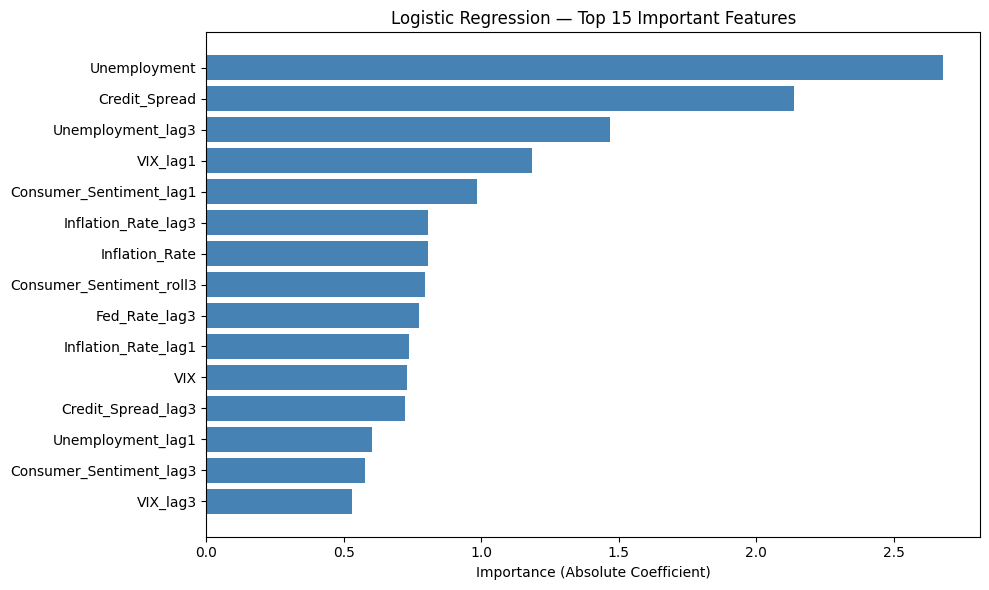

                     Feature  Importance
2               Unemployment    2.679164
3              Credit_Spread    2.137303
17         Unemployment_lag3    1.467256
7                   VIX_lag1    1.185385
12   Consumer_Sentiment_lag1    0.984407
20       Inflation_Rate_lag3    0.805576
6             Inflation_Rate    0.804514
26  Consumer_Sentiment_roll3    0.794635
16             Fed_Rate_lag3    0.774097
13       Inflation_Rate_lag1    0.735729
0                        VIX    0.730190
18        Credit_Spread_lag3    0.721772
10         Unemployment_lag1    0.601829
19   Consumer_Sentiment_lag3    0.576121
14                  VIX_lag3    0.528283


In [30]:
feature_names = X.columns.tolist()
lr_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(lr.coef_[0])
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(lr_importance['Feature'][::-1], lr_importance['Importance'][::-1], color='steelblue')
plt.title('Logistic Regression — Top 15 Important Features')
plt.xlabel('Importance (Absolute Coefficient)')
plt.tight_layout()
plt.show()

print(lr_importance)

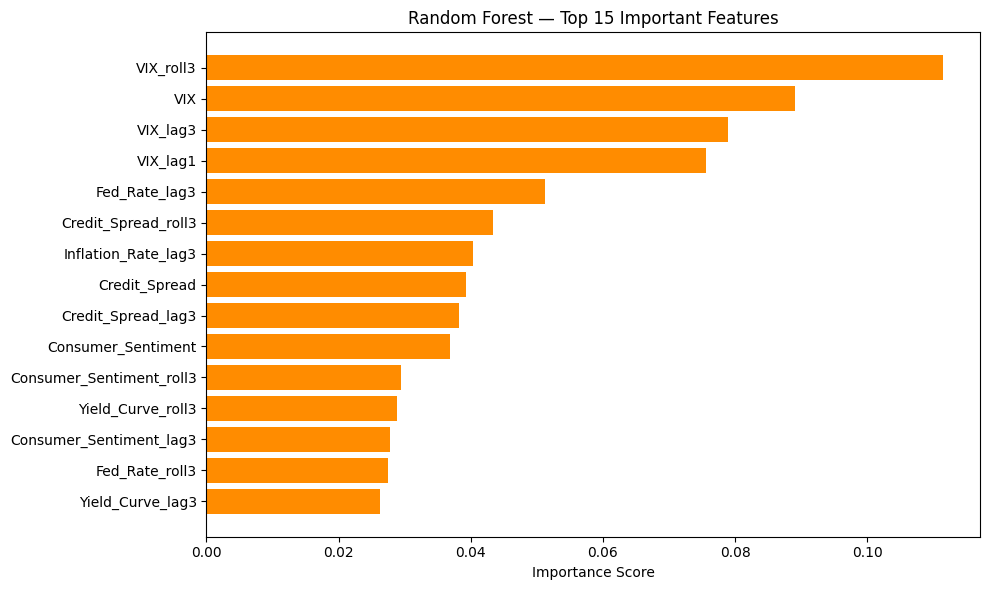

                     Feature  Importance
21                 VIX_roll3    0.111489
0                        VIX    0.088990
14                  VIX_lag3    0.078957
7                   VIX_lag1    0.075616
16             Fed_Rate_lag3    0.051181
25       Credit_Spread_roll3    0.043373
20       Inflation_Rate_lag3    0.040270
3              Credit_Spread    0.039209
18        Credit_Spread_lag3    0.038235
4         Consumer_Sentiment    0.036811
26  Consumer_Sentiment_roll3    0.029453
22         Yield_Curve_roll3    0.028875
19   Consumer_Sentiment_lag3    0.027722
23            Fed_Rate_roll3    0.027525
15          Yield_Curve_lag3    0.026204


In [31]:
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(rf_importance['Feature'][::-1], rf_importance['Importance'][::-1], color='darkorange')
plt.title('Random Forest — Top 15 Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(rf_importance)

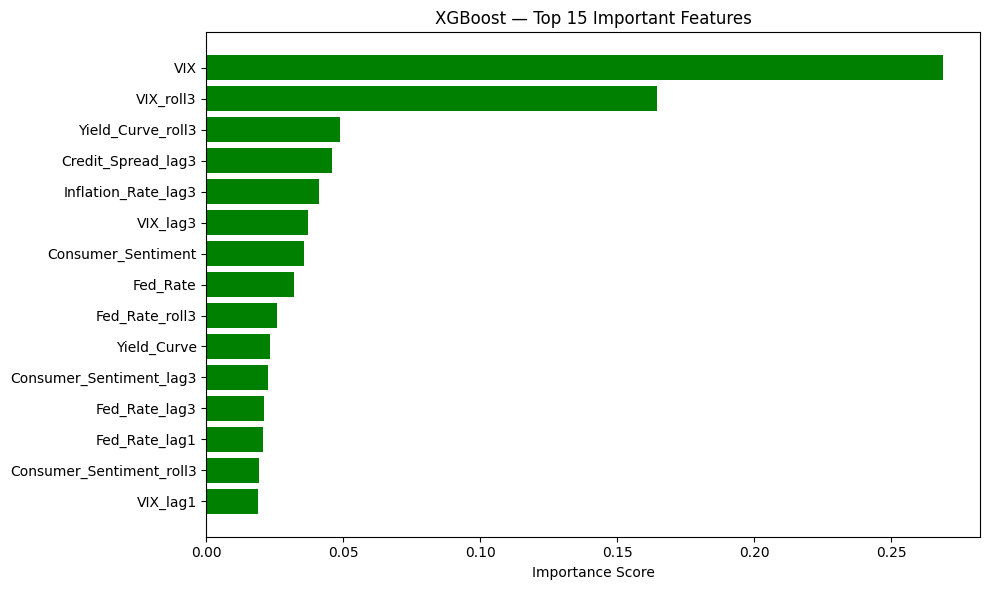

                     Feature  Importance
0                        VIX    0.268904
21                 VIX_roll3    0.164601
22         Yield_Curve_roll3    0.048787
18        Credit_Spread_lag3    0.045987
20       Inflation_Rate_lag3    0.040975
14                  VIX_lag3    0.037011
4         Consumer_Sentiment    0.035702
1                   Fed_Rate    0.031836
23            Fed_Rate_roll3    0.025916
5                Yield_Curve    0.023324
19   Consumer_Sentiment_lag3    0.022401
16             Fed_Rate_lag3    0.021160
9              Fed_Rate_lag1    0.020715
26  Consumer_Sentiment_roll3    0.019069
7                   VIX_lag1    0.018676


In [32]:
xgb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(xgb_importance['Feature'][::-1], xgb_importance['Importance'][::-1], color='green')
plt.title('XGBoost — Top 15 Important Features')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(xgb_importance)

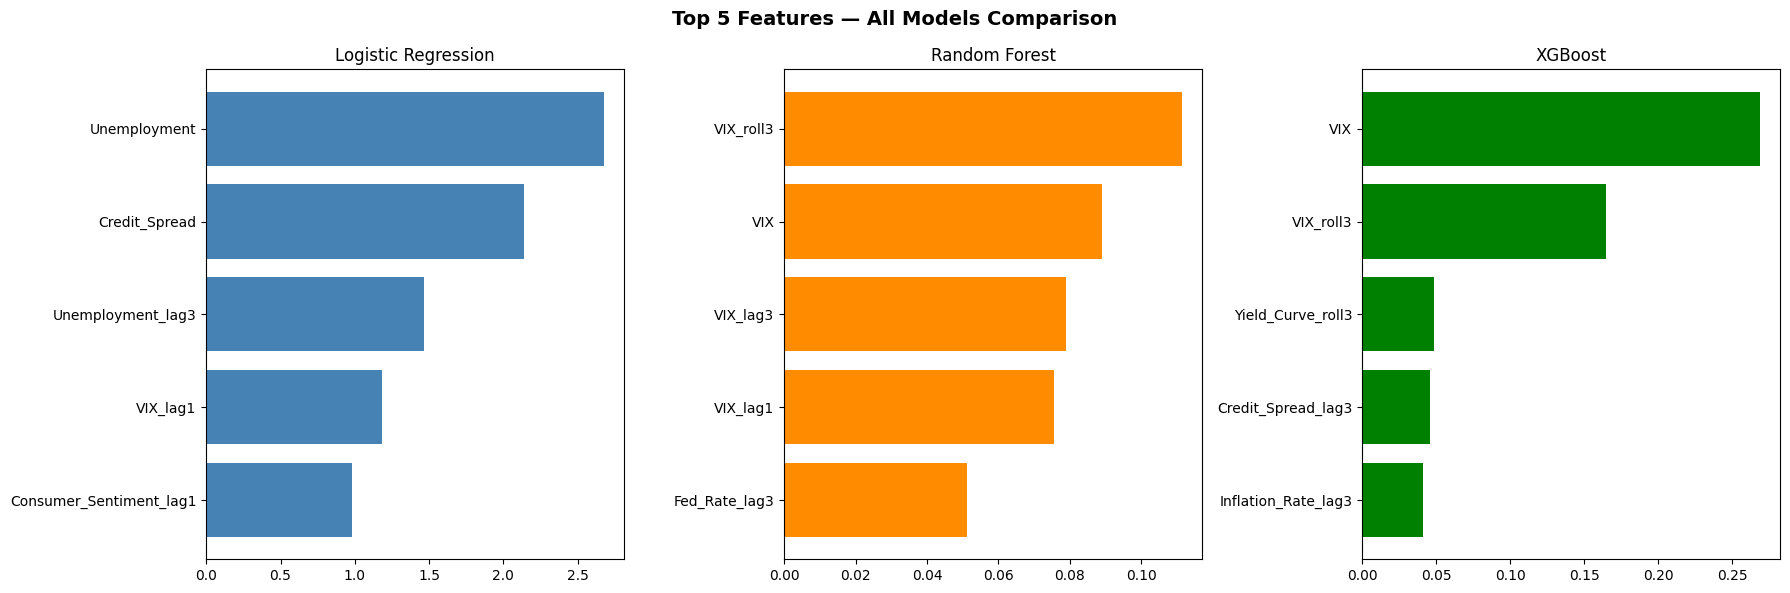

In [33]:

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# LR
axes[0].barh(lr_importance['Feature'][:5][::-1],
             lr_importance['Importance'][:5][::-1], color='steelblue')
axes[0].set_title('Logistic Regression')

# RF
axes[1].barh(rf_importance['Feature'][:5][::-1],
             rf_importance['Importance'][:5][::-1], color='darkorange')
axes[1].set_title('Random Forest')

# XGBoost
axes[2].barh(xgb_importance['Feature'][:5][::-1],
             xgb_importance['Importance'][:5][::-1], color='green')
axes[2].set_title('XGBoost')

plt.suptitle('Top 5 Features — All Models Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
latest = df.iloc[-1]
print(latest)

SP500                       5906.939941
VIX                           17.400000
Fed_Rate                       4.480000
Unemployment                   4.100000
Credit_Spread                  1.409524
Consumer_Sentiment            74.000000
Yield_Curve                    0.165714
Inflation_Rate                 2.870691
Target                         0.000000
VIX_lag1                      13.510000
Yield_Curve_lag1               0.098421
Fed_Rate_lag1                  4.640000
Unemployment_lag1              4.200000
Credit_Spread_lag1             1.421579
Consumer_Sentiment_lag1       71.800000
Inflation_Rate_lag1            2.719472
VIX_lag3                      16.730000
Yield_Curve_lag3               0.101000
Fed_Rate_lag3                  5.130000
Unemployment_lag3              4.100000
Credit_Spread_lag3             1.694500
Consumer_Sentiment_lag3       70.100000
Inflation_Rate_lag3            2.426483
VIX_roll3                     18.023333
Yield_Curve_roll3              0.129106


In [35]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=False)

model_list = {
    'Logistic Regression': (lr, X_train_scaled),
    'Random Forest':       (rf, X_train_smote),
    'XGBoost':             (xgb, X_train_smote),
}

for name, (model, X) in model_list.items():
    scores = cross_val_score(model, X, y_train_smote,
                             cv=skf, scoring='roc_auc')
    print(f"\n{name}")
    print(f"  ROC-AUC per fold: {[round(s,3) for s in scores]}")
    print(f"  Average ROC-AUC: {scores.mean():.3f} (+/- {scores.std():.3f})")


Logistic Regression
  ROC-AUC per fold: [np.float64(0.358), np.float64(0.364), np.float64(0.659), np.float64(0.381), np.float64(0.913)]
  Average ROC-AUC: 0.535 (+/- 0.220)

Random Forest
  ROC-AUC per fold: [np.float64(0.997), np.float64(0.774), np.float64(0.888), np.float64(0.943), np.float64(1.0)]
  Average ROC-AUC: 0.920 (+/- 0.084)

XGBoost
  ROC-AUC per fold: [np.float64(0.975), np.float64(0.441), np.float64(0.869), np.float64(0.737), np.float64(1.0)]
  Average ROC-AUC: 0.805 (+/- 0.204)


In [36]:
from sklearn.metrics import roc_curve

print("Best Threshold per Model:\n")

best_thresholds = {}

for name, (model, X) in models.items():
    y_prob = model.predict_proba(X)[:, 1]


    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    best_idx = np.argmax(tpr - fpr)
    best_thresh = thresholds[best_idx]
    best_thresholds[name] = best_thresh

    y_pred = (y_prob >= best_thresh).astype(int)
    print(f"{name}")
    print(f"  Best threshold: {best_thresh:.2f}")
    print(classification_report(y_test, y_pred, target_names=['Safe', 'Crash']))
    print(f"  ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}\n")

Best Threshold per Model:

Logistic Regression
  Best threshold: 0.03
              precision    recall  f1-score   support

        Safe       1.00      0.51      0.67        75
       Crash       0.14      1.00      0.24         6

    accuracy                           0.54        81
   macro avg       0.57      0.75      0.46        81
weighted avg       0.94      0.54      0.64        81

  ROC-AUC: 0.684

Random Forest
  Best threshold: 0.29
              precision    recall  f1-score   support

        Safe       0.94      0.77      0.85        75
       Crash       0.11      0.33      0.16         6

    accuracy                           0.74        81
   macro avg       0.52      0.55      0.50        81
weighted avg       0.87      0.74      0.80        81

  ROC-AUC: 0.394

XGBoost
  Best threshold: 0.14
              precision    recall  f1-score   support

        Safe       0.94      0.68      0.79        75
       Crash       0.11      0.50      0.18         6

    accu

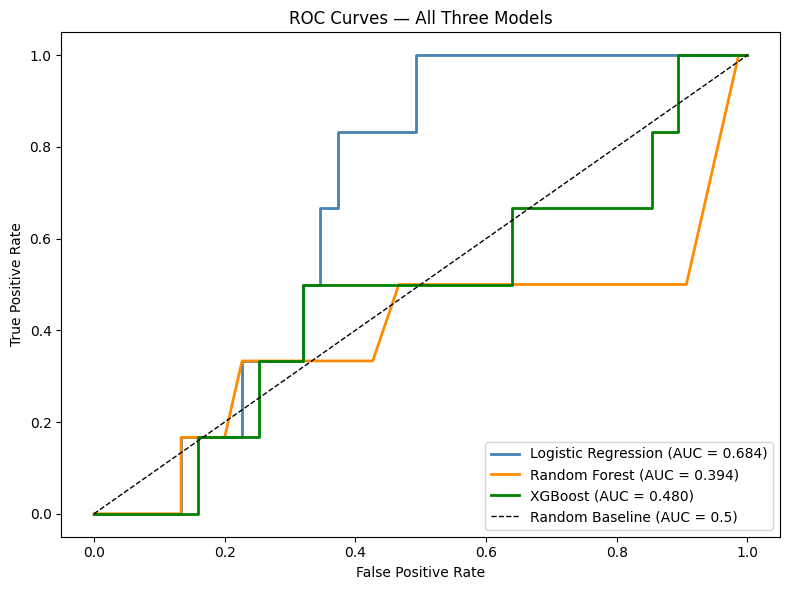

In [37]:
# ROC Curves - all 3 models on one plot
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(8, 6))

colors = {
    'Logistic Regression': 'steelblue',
    'Random Forest': 'darkorange',
    'XGBoost': 'green'
}

for name, (model, X) in models.items():
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})',
             color=colors[name], linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Baseline (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Three Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

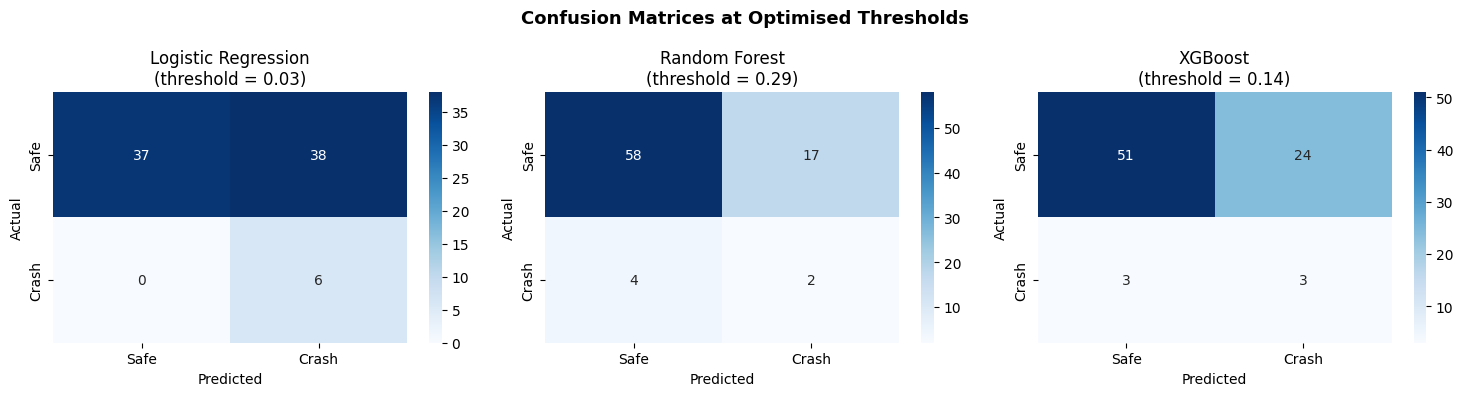

In [38]:
# Confusion matrices for all 3 models at their optimised thresholds
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_thresholds = {
    'Logistic Regression': (lr, X_test_scaled, 0.03),
    'Random Forest':       (rf, X_test, 0.29),
    'XGBoost':             (xgb, X_test, 0.14)
}

for ax, (name, (model, X, thresh)) in zip(axes, model_thresholds.items()):
    y_prob = model.predict_proba(X)[:, 1]
    y_pred = (y_prob >= thresh).astype(int)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Safe', 'Crash'],
                yticklabels=['Safe', 'Crash'])
    ax.set_title(f'{name}\n(threshold = {thresh})')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices at Optimised Thresholds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**STEP 8 — SHAP Explainability Analysis**

In [39]:
import shap

In [40]:
# ── 8.1  SHAP for Logistic Regression (our best model) ──────

print("Calculating SHAP values for Logistic Regression...")

# We use LinearExplainer for Logistic Regression
# It's faster and designed specifically for linear models

explainer_lr = shap.LinearExplainer(lr, X_test_scaled, feature_perturbation="interventional")
shap_values_lr = explainer_lr.shap_values(X_test_scaled)

print(f"SHAP values shape: {shap_values_lr.shape}")
print("Done! Generating plots...")


Calculating SHAP values for Logistic Regression...
SHAP values shape: (81, 28)
Done! Generating plots...


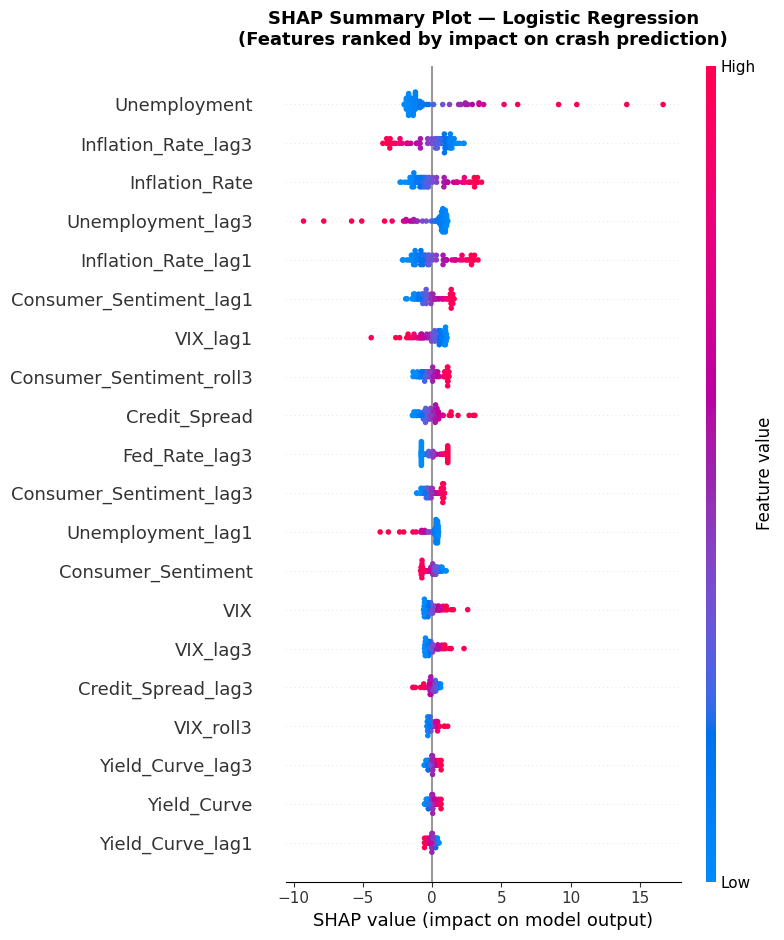

Saved: shap_summary_lr.png


In [41]:
# ── 8.2  Summary Plot (Beeswarm) — Logistic Regression ──────
# This is the most important SHAP plot.

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_lr,
    X_test_scaled,
    feature_names=X_test.columns.tolist(),
    show=False,
    plot_type="dot"
)
plt.title("SHAP Summary Plot — Logistic Regression\n(Features ranked by impact on crash prediction)",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_summary_lr.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_lr.png")

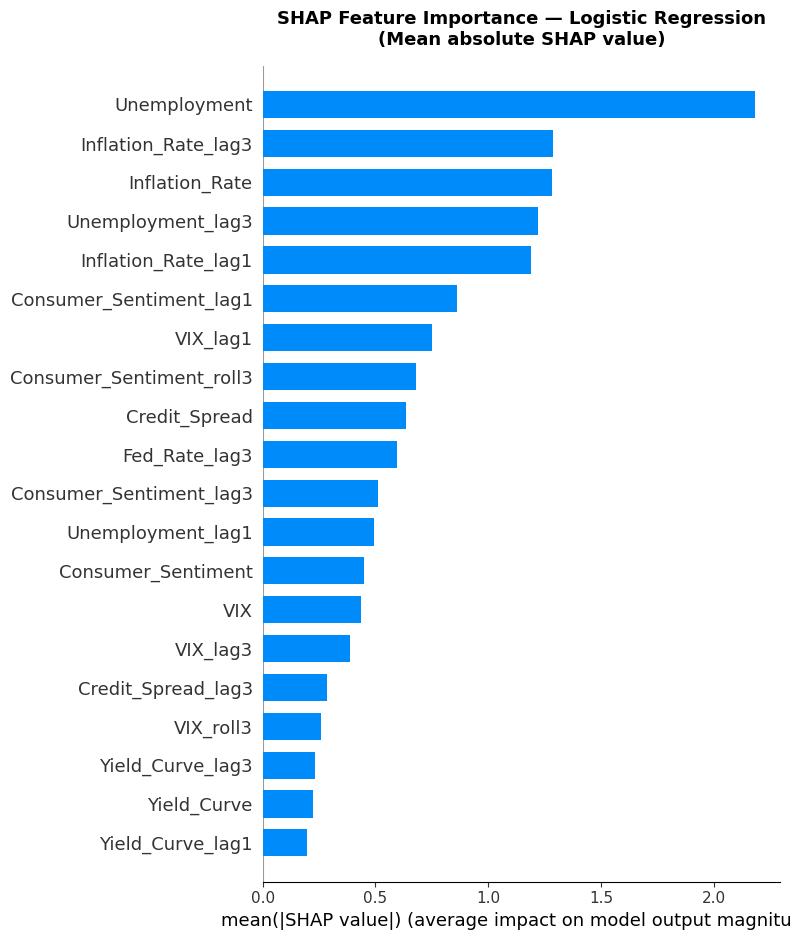

Saved: shap_bar_lr.png


In [42]:
# ── 8.3  Bar Plot — Mean Absolute SHAP Values ───────────────

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_lr,
    X_test_scaled,
    feature_names=X_test.columns.tolist(),
    show=False,
    plot_type="bar"
)
plt.title("SHAP Feature Importance — Logistic Regression\n(Mean absolute SHAP value)",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_bar_lr.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar_lr.png")

Test sample index: 2
Actual: SAFE
Predicted: CRASH
Crash probability: 0.2302


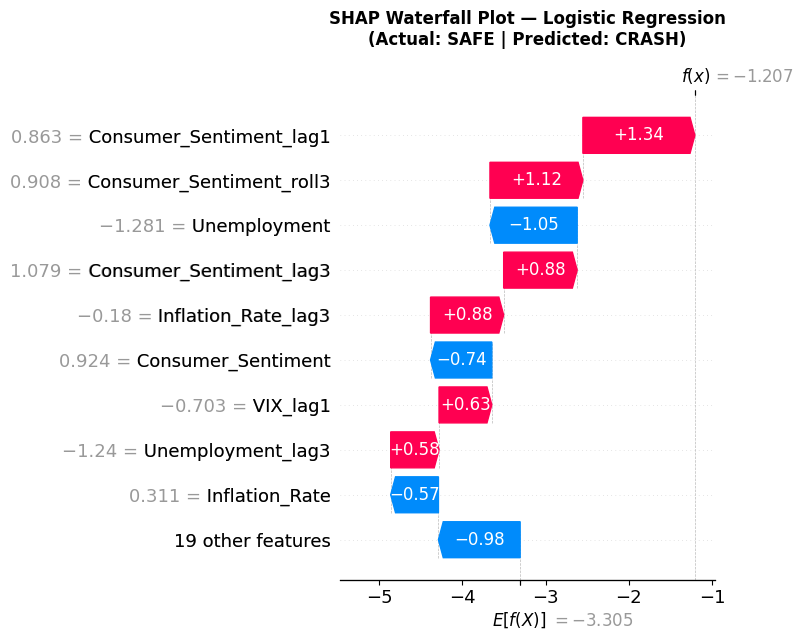

Saved: shap_waterfall_lr.png


In [43]:
# ── Waterfall Plot — Logistic Regression ────────────────────

y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr = (y_prob_lr >= 0.2).astype(int)

crash_idx_lr = [i for i, v in enumerate(y_pred_lr) if v == 1]

if len(crash_idx_lr) == 0:
    print("No crash predictions from LR — using highest probability month instead")
    sample_idx_lr = int(y_prob_lr.argmax())
else:
    sample_idx_lr = crash_idx_lr[0]
    print(f"Test sample index: {sample_idx_lr}")
    print(f"Actual: {'CRASH' if y_test.iloc[sample_idx_lr] == 1 else 'SAFE'}")
    print(f"Predicted: {'CRASH' if y_pred_lr[sample_idx_lr] == 1 else 'SAFE'}")
    print(f"Crash probability: {y_prob_lr[sample_idx_lr]:.4f}")

shap_explanation_lr = shap.Explanation(
    values=shap_values_lr[sample_idx_lr],
    base_values=explainer_lr.expected_value,
    data=X_test_scaled[sample_idx_lr],
    feature_names=X_test.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_explanation_lr, show=False)
plt.title(f"SHAP Waterfall Plot — Logistic Regression\n(Actual: {'CRASH' if y_test.iloc[sample_idx_lr]==1 else 'SAFE'} | Predicted: {'CRASH' if y_pred_lr[sample_idx_lr]==1 else 'SAFE'})",
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_waterfall_lr.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall_lr.png")

Calculating SHAP values for Random Forest...
SHAP values shape: (81, 28, 2)
Done! Generating plots...


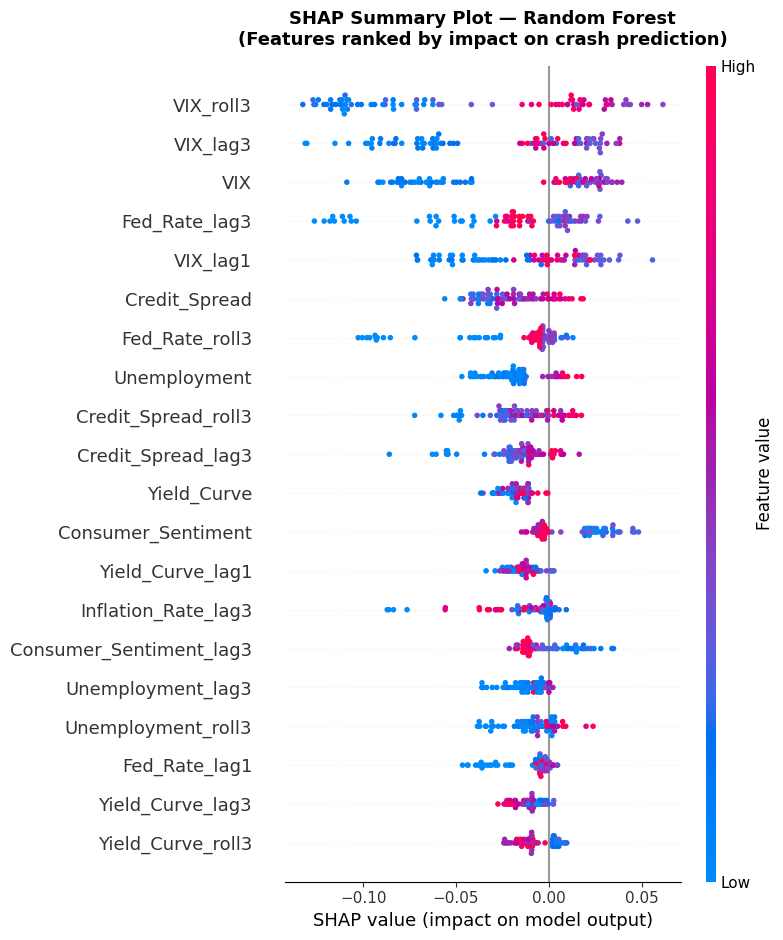

Saved: shap_summary_rf.png


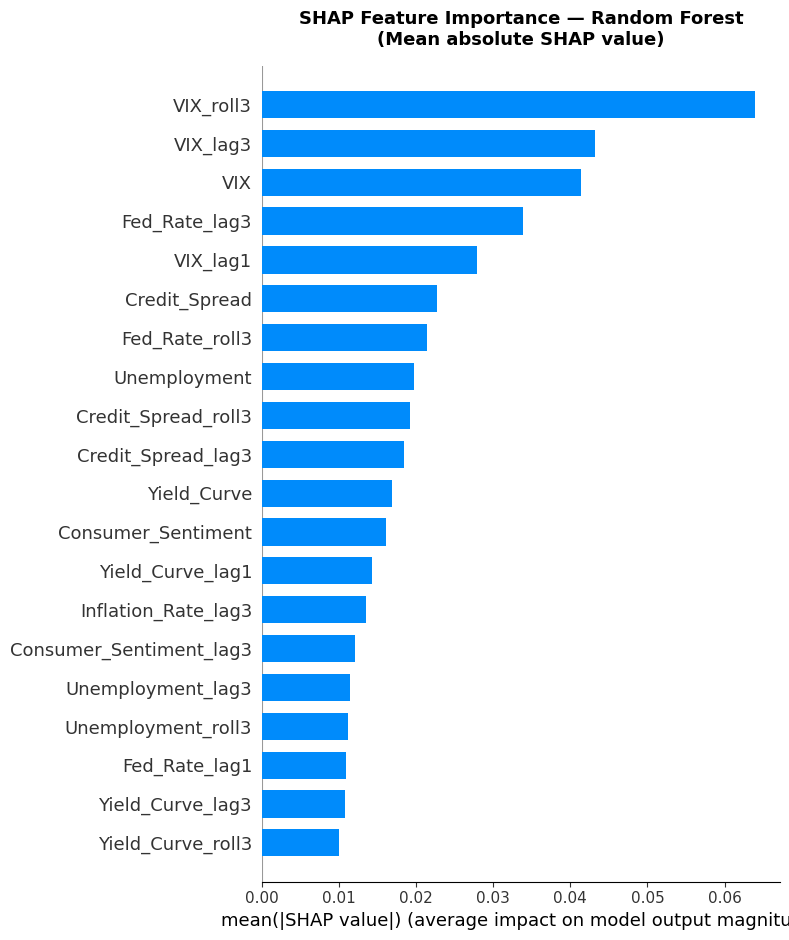

Saved: shap_bar_rf.png


In [44]:
# ── 8.5  SHAP for Random Forest ──────────────────────────────

print("Calculating SHAP values for Random Forest...")

# TreeExplainer is used for tree-based models
# it is much faster and more accurate for Random Forest than the general explainer
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)

print(f"SHAP values shape: {shap_values_rf.shape}")
print("Done! Generating plots...")


# ── 8.6  Summary Plot (Beeswarm) — Random Forest ────────────

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_rf[:, :, 1],
    X_test,
    feature_names=X_test.columns.tolist(),
    show=False,
    plot_type="dot"
)
plt.title("SHAP Summary Plot — Random Forest\n(Features ranked by impact on crash prediction)",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_summary_rf.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_rf.png")


# ── 8.7  Bar Plot — Random Forest ───────────────────────────

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_rf[:, :, 1],
    X_test,
    feature_names=X_test.columns.tolist(),
    show=False,
    plot_type="bar"
)
plt.title("SHAP Feature Importance — Random Forest\n(Mean absolute SHAP value)",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_bar_rf.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar_rf.png")

Test sample index: 8
Actual: SAFE
Predicted: CRASH
Crash probability: 0.2700


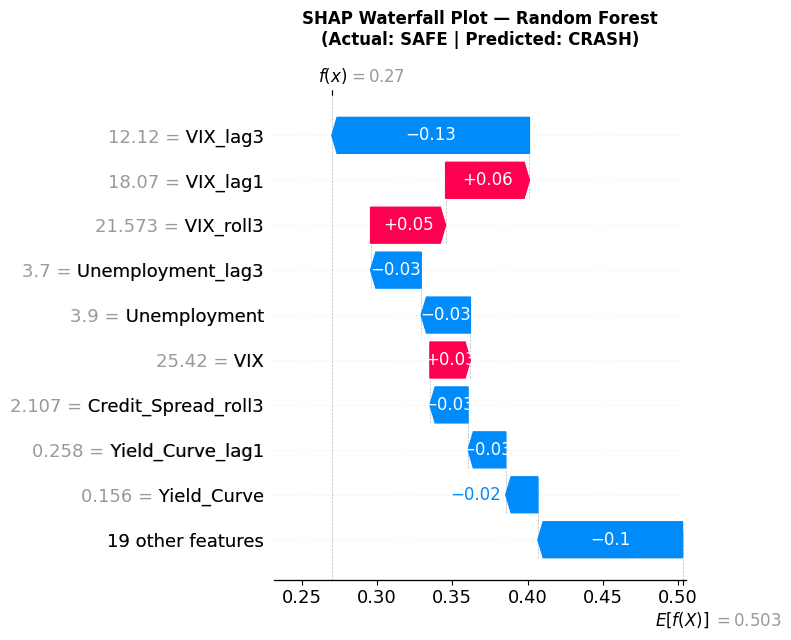

Saved: shap_waterfall_rf.png


In [45]:
# ── Waterfall Plot — Random Forest ──────────────────────────

y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.2).astype(int)

crash_idx_rf = [i for i, v in enumerate(y_pred_rf) if v == 1]

if len(crash_idx_rf) == 0:
    print("No crash predictions from RF — using highest probability month instead")
    sample_idx_rf = int(y_prob_rf.argmax())
else:
    sample_idx_rf = crash_idx_rf[0]
    print(f"Test sample index: {sample_idx_rf}")
    print(f"Actual: {'CRASH' if y_test.iloc[sample_idx_rf] == 1 else 'SAFE'}")
    print(f"Predicted: {'CRASH' if y_pred_rf[sample_idx_rf] == 1 else 'SAFE'}")
    print(f"Crash probability: {y_prob_rf[sample_idx_rf]:.4f}")

shap_explanation_rf = shap.Explanation(
    values=shap_values_rf[sample_idx_rf, :, 1],
    base_values=explainer_rf.expected_value[1],
    data=X_test.iloc[sample_idx_rf].values,
    feature_names=X_test.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_explanation_rf, show=False)
plt.title(f"SHAP Waterfall Plot — Random Forest\n(Actual: {'CRASH' if y_test.iloc[sample_idx_rf]==1 else 'SAFE'} | Predicted: {'CRASH' if y_pred_rf[sample_idx_rf]==1 else 'SAFE'})",
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_waterfall_rf.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall_rf.png")

Calculating SHAP values for XGBoost...
SHAP values shape: (81, 28)
Done! Generating plots...


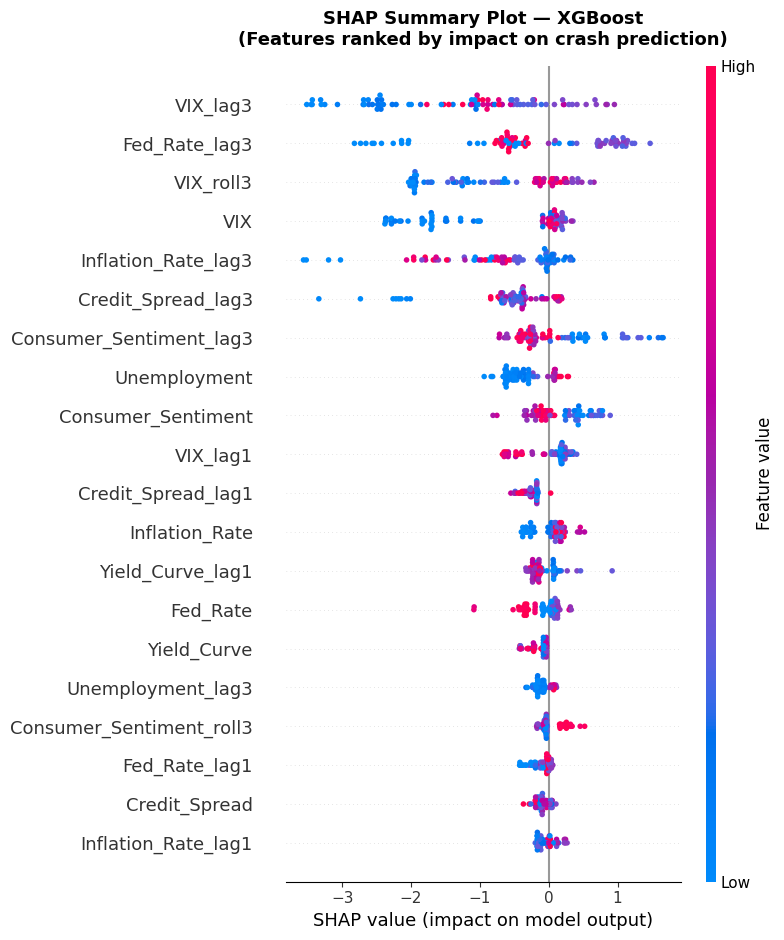

Saved: shap_summary_xgb.png


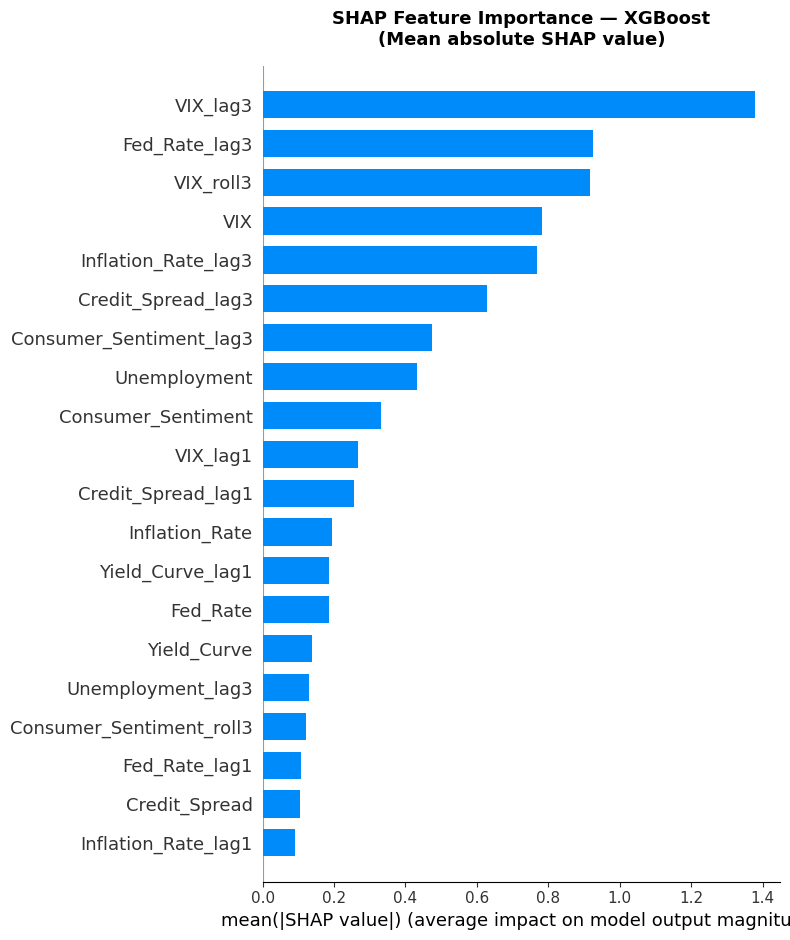

Saved: shap_bar_xgb.png


In [46]:
# ── 8.8  SHAP for XGBoost ────────────────────────────────────

print("Calculating SHAP values for XGBoost...")

# same TreeExplainer works for XGBoost as well
explainer_xgb = shap.TreeExplainer(xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)

print(f"SHAP values shape: {shap_values_xgb.shape}")
print("Done! Generating plots...")


# ── 8.9  Summary Plot (Beeswarm) — XGBoost ──────────────────

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_xgb,
    X_test,
    feature_names=X_test.columns.tolist(),
    show=False,
    plot_type="dot"
)
plt.title("SHAP Summary Plot — XGBoost\n(Features ranked by impact on crash prediction)",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_summary_xgb.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary_xgb.png")


# ── 8.10  Bar Plot — XGBoost ────────────────────────────────

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values_xgb,
    X_test,
    feature_names=X_test.columns.tolist(),
    show=False,
    plot_type="bar"
)
plt.title("SHAP Feature Importance — XGBoost\n(Mean absolute SHAP value)",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_bar_xgb.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_bar_xgb.png")

Test sample index: 8
Actual: SAFE
Predicted: CRASH
Crash probability: 0.2534


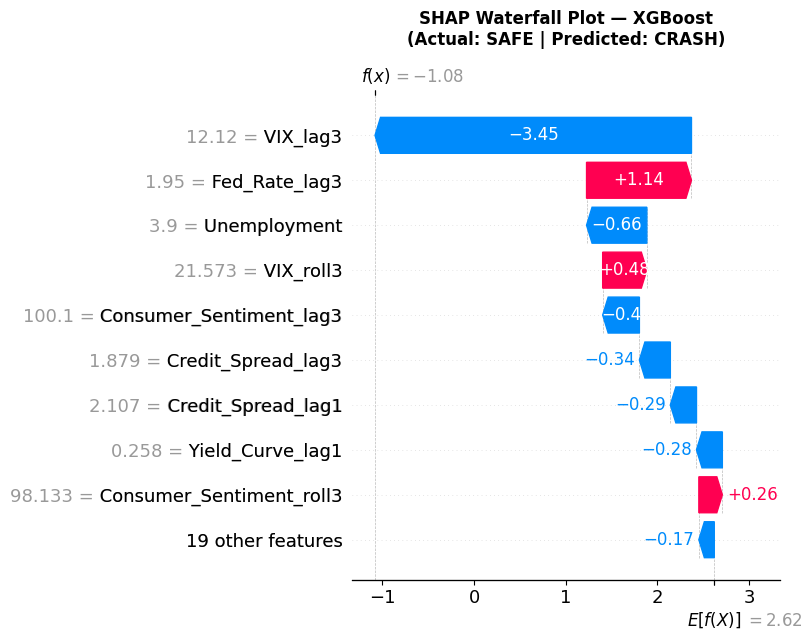

Saved: shap_waterfall_xgb.png


In [47]:
# ── Waterfall Plot — XGBoost ─────────────────────────────────

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.2).astype(int)

crash_idx_xgb = [i for i, v in enumerate(y_pred_xgb) if v == 1]

if len(crash_idx_xgb) == 0:
    print("No crash predictions from XGBoost — using highest probability month instead")
    sample_idx_xgb = int(y_prob_xgb.argmax())
else:
    sample_idx_xgb = crash_idx_xgb[0]
    print(f"Test sample index: {sample_idx_xgb}")
    print(f"Actual: {'CRASH' if y_test.iloc[sample_idx_xgb] == 1 else 'SAFE'}")
    print(f"Predicted: {'CRASH' if y_pred_xgb[sample_idx_xgb] == 1 else 'SAFE'}")
    print(f"Crash probability: {y_prob_xgb[sample_idx_xgb]:.4f}")

shap_explanation_xgb = shap.Explanation(
    values=shap_values_xgb[sample_idx_xgb],
    base_values=explainer_xgb.expected_value,
    data=X_test.iloc[sample_idx_xgb].values,
    feature_names=X_test.columns.tolist()
)

plt.figure(figsize=(10, 7))
shap.waterfall_plot(shap_explanation_xgb, show=False)
plt.title(f"SHAP Waterfall Plot — XGBoost\n(Actual: {'CRASH' if y_test.iloc[sample_idx_xgb]==1 else 'SAFE'} | Predicted: {'CRASH' if y_pred_xgb[sample_idx_xgb]==1 else 'SAFE'})",
          fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("shap_waterfall_xgb.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_waterfall_xgb.png")

In [48]:
# ── 8.11  Comparison Table — All 3 Models ───────────────────

lr_importance = pd.DataFrame({
    'Feature': X_test.columns.tolist(),
    'LR_SHAP': np.abs(shap_values_lr).mean(axis=0)
})

rf_importance = pd.DataFrame({
    'Feature': X_test.columns.tolist(),
    'RF_SHAP': np.abs(shap_values_rf[:, :, 1]).mean(axis=0)
})

xgb_importance = pd.DataFrame({
    'Feature': X_test.columns.tolist(),
    'XGB_SHAP': np.abs(shap_values_xgb).mean(axis=0)
})

# merge all three and sort by LR importance
comparison = lr_importance.merge(rf_importance, on='Feature').merge(xgb_importance, on='Feature')
comparison = comparison.sort_values('LR_SHAP', ascending=False).reset_index(drop=True)
comparison.index += 1

print("=== SHAP Feature Importance Comparison Across All 3 Models ===\n")
print(comparison.to_string())

=== SHAP Feature Importance Comparison Across All 3 Models ===

                     Feature   LR_SHAP   RF_SHAP  XGB_SHAP
1               Unemployment  2.184462  0.019768  0.431940
2        Inflation_Rate_lag3  1.287547  0.013458  0.767288
3             Inflation_Rate  1.283414  0.009267  0.194431
4          Unemployment_lag3  1.218796  0.011460  0.130450
5        Inflation_Rate_lag1  1.191630  0.007250  0.091153
6    Consumer_Sentiment_lag1  0.862674  0.005169  0.069540
7                   VIX_lag1  0.751583  0.027933  0.268018
8   Consumer_Sentiment_roll3  0.681317  0.009021  0.122180
9              Credit_Spread  0.636446  0.022736  0.105015
10             Fed_Rate_lag3  0.596650  0.033834  0.924244
11   Consumer_Sentiment_lag3  0.510935  0.012131  0.475716
12         Unemployment_lag1  0.492643  0.009046  0.020276
13        Consumer_Sentiment  0.449486  0.016151  0.330250
14                       VIX  0.438337  0.041412  0.781743
15                  VIX_lag3  0.388254  0.043145  1

**STEP 9 — Interactive Market Early Warning Dashboard**

In [49]:

# SECTION 9 — INTERACTIVE MARKET RISK DASHBOARD

# builds an interactive dashboard showing:
# 1. current status of all economic indicators
# 2. crash probability from all 3 models
# 3. historical trends of key indicators


import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.offline as pyo

In [50]:
#  9.1  Get Latest Data and Run Models

latest_features = df.drop(columns=['Target', 'SP500']).iloc[[-1]]
latest_date = df.index[-1].strftime('%B %Y')

latest_scaled = scaler.transform(latest_features)

prob_lr  = lr.predict_proba(latest_scaled)[0][1]
prob_rf  = rf.predict_proba(latest_features)[0][1]
prob_xgb = xgb.predict_proba(latest_features)[0][1]

status_lr  = 'CRASH WARNING' if prob_lr  >= 0.2 else 'SAFE'
status_rf  = 'CRASH WARNING' if prob_rf  >= 0.2 else 'SAFE'
status_xgb = 'CRASH WARNING' if prob_xgb >= 0.2 else 'SAFE'

overall_status = status_lr
overall_color  = '#ff4757' if overall_status == 'CRASH WARNING' else '#2ed573'

print(f"Data as of: {latest_date}")
print(f"LR:  {prob_lr:.1%}  → {status_lr}")
print(f"RF:  {prob_rf:.1%}  → {status_rf}")
print(f"XGB: {prob_xgb:.1%} → {status_xgb}")

Data as of: December 2024
LR:  0.5%  → SAFE
RF:  3.0%  → SAFE
XGB: 40.7% → CRASH WARNING


In [51]:
# 9.2  Indicator Thresholds

indicators = {
    'VIX':                {'danger_above': 25,  'danger_below': None},
    'Yield_Curve':        {'danger_above': None, 'danger_below': 0},
    'Fed_Rate':           {'danger_above': 5,   'danger_below': None},
    'Unemployment':       {'danger_above': 6,   'danger_below': None},
    'Credit_Spread':      {'danger_above': 3,   'danger_below': None},
    'Consumer_Sentiment': {'danger_above': None, 'danger_below': 70},
    'Inflation_Rate':     {'danger_above': 4,   'danger_below': None},
}

latest_row = df.iloc[-1]

def get_status(feature, value):
    info = indicators[feature]
    if info['danger_above'] is not None and value > info['danger_above']:
        return 'DANGER', '#ff4757'
    if info['danger_below'] is not None and value < info['danger_below']:
        return 'DANGER', '#ff4757'
    return 'NORMAL', '#2ed573'

In [52]:
#  9.3  Build Dashboard

df_recent = df[df.index >= '2015-01-01']

fig = make_subplots(
    rows=3, cols=3,
    # empty strings for gauge row so titles dont duplicate
    subplot_titles=(
        '', '', '',
        'VIX — Fear Index', 'Yield Curve', 'Credit Spread',
        'Unemployment Rate', 'Inflation Rate', 'Consumer Sentiment'
    ),
    specs=[
        [{'type': 'indicator'}, {'type': 'indicator'}, {'type': 'indicator'}],
        [{'type': 'xy'},        {'type': 'xy'},         {'type': 'xy'}],
        [{'type': 'xy'},        {'type': 'xy'},         {'type': 'xy'}],
    ],
    vertical_spacing=0.12,
    horizontal_spacing=0.08
)

#  Gauge charts

gauge_data = [
    (prob_lr,  status_lr,  'Logistic Regression', 1),
    (prob_rf,  status_rf,  'Random Forest',        2),
    (prob_xgb, status_xgb, 'XGBoost',              3),
]

for prob, status, name, col in gauge_data:
    bar_color = '#ff4757' if status == 'CRASH WARNING' else '#2ed573'
    fig.add_trace(go.Indicator(
        mode="gauge+number",
        value=round(prob * 100, 1),
        title={
            'text': f"<b>{name}</b><br><span style='color:{bar_color};font-size:15px'>{status}</span>",
            'font': {'size': 13, 'color': '#2d3436'}
        },
        number={'suffix': '%', 'font': {'size': 32, 'color': '#2d3436'}},
        gauge={
            'axis': {'range': [0, 100], 'tickcolor': '#636e72', 'tickfont': {'color': '#636e72'}},
            'bar': {'color': bar_color, 'thickness': 0.3},
            'bgcolor': '#f8f9fa',
            'borderwidth': 0,
            'steps': [
                {'range': [0,  20],  'color': '#d5f5e3'},
                {'range': [20, 50],  'color': '#fdebd0'},
                {'range': [50, 100], 'color': '#fadbd8'},
            ],
            'threshold': {
                'line': {'color': '#ff6b81', 'width': 3},
                'thickness': 0.75,
                'value': 20
            }
        }
    ), row=1, col=col)

#  Trend charts

trend_features = [
    ('VIX',                '#70a1ff', 25,   None, 2, 1),
    ('Yield_Curve',        '#a29bfe', None, 0,    2, 2),
    ('Credit_Spread',      '#fd9644', 3,    None, 2, 3),
    ('Unemployment',       '#ff6b81', 6,    None, 3, 1),
    ('Inflation_Rate',     '#ffd32a', 4,    None, 3, 2),
    ('Consumer_Sentiment', '#0be881', None, 70,   3, 3),
]

for feature, color, danger_above, danger_below, row, col in trend_features:
    # main line
    fig.add_trace(go.Scatter(
        x=df_recent.index,
        y=df_recent[feature],
        mode='lines',
        line={'color': color, 'width': 2.5},
        showlegend=False,
        hovertemplate='%{x|%b %Y}<br>Value: %{y:.2f}<extra></extra>'
    ), row=row, col=col)

    # danger threshold
    threshold_val = danger_above if danger_above is not None else danger_below
    fig.add_trace(go.Scatter(
        x=[df_recent.index[0], df_recent.index[-1]],
        y=[threshold_val, threshold_val],
        mode='lines',
        line={'color': '#ff4757', 'width': 1.5, 'dash': 'dash'},
        showlegend=False,
        hoverinfo='skip'
    ), row=row, col=col)

    # current value dot
    current_val = latest_row[feature]
    dot_color = get_status(feature, current_val)[1]
    fig.add_trace(go.Scatter(
        x=[df.index[-1]],
        y=[current_val],
        mode='markers',
        marker={'color': dot_color, 'size': 12, 'symbol': 'circle',
                'line': {'color': '#ffffff', 'width': 2}},
        showlegend=False,
        hovertemplate=f'Now ({latest_date}): {current_val:.2f}<extra></extra>'
    ), row=row, col=col)
print("Dashboard ready!")

Dashboard ready!


In [53]:
#  9.4  Style and Save

# light background for all chart areas
fig.update_xaxes(showgrid=True, gridcolor='#e0e0e0', gridwidth=1,
                 tickfont={'color': '#636e72'}, linecolor='#e0e0e0')
fig.update_yaxes(showgrid=True, gridcolor='#e0e0e0', gridwidth=1,
                 tickfont={'color': '#636e72'}, linecolor='#e0e0e0')

# style the subplot titles
for annotation in fig.layout.annotations:
    annotation.font.color = '#2d3436'
    annotation.font.size  = 13

fig.update_layout(
    title={
        'text': (
            f"<b style='font-size:30px;color:#2d3436'>Market Crash Early Warning System</b><br>"
            f"<span style='font-size:15px;color:#2d3436'>Data as of {latest_date}   |   "
            f"Best Model (LR) Status: "
            f"<b style='color:{overall_color}'>{overall_status}</b></span>"
        ),
        'x': 0.5,
        'xanchor': 'center',
        'font': {'color': '#ffffff'}
    },
    height=1100,
    margin={'t': 150, 'b': 40, 'l': 40, 'r': 40},
    showlegend=False,
    paper_bgcolor='#ffffff',
    plot_bgcolor='#f8f9fa',
    font={'family': 'Arial', 'color': '#2d3436'}
)

fig.write_html("/Users/swaransh/DataspellProjects/Advanced Computing project/market_risk_dashboard.html")
print("Saved! Open market_risk_dashboard.html in your browser")

Saved! Open market_risk_dashboard.html in your browser
